In [1]:
# K-means Clustering And Silhouette Score

In [ ]:
# Elbow Method:
# (Within Cluster Sum of Sqaures)
# WCSS= Σpi in Clusteri distance (Pi C₁)2 + Σpi in Cluster2distance(Pi C₂)2 + Σpi in Cluster3 distance(Pi C3)2

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
dataset = pd.read_csv("unlabel_Iris.csv")
dataset.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


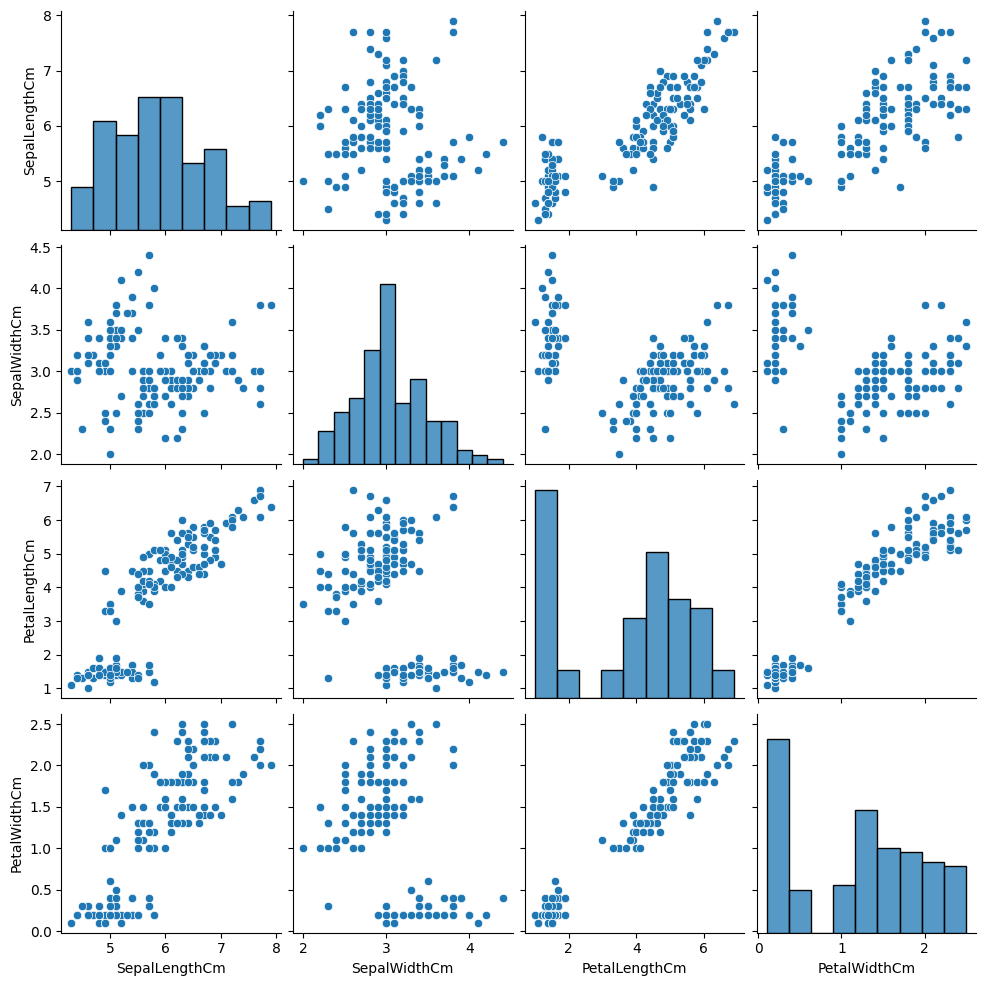

In [25]:
sns.pairplot(data=dataset)
plt.show()

In [26]:
from sklearn.cluster import KMeans

In [27]:
wcss = []

for i in range(2, 23):
    km = KMeans(n_clusters=i, init='k-means++')
    km.fit(dataset)
    wcss.append(km.inertia_)

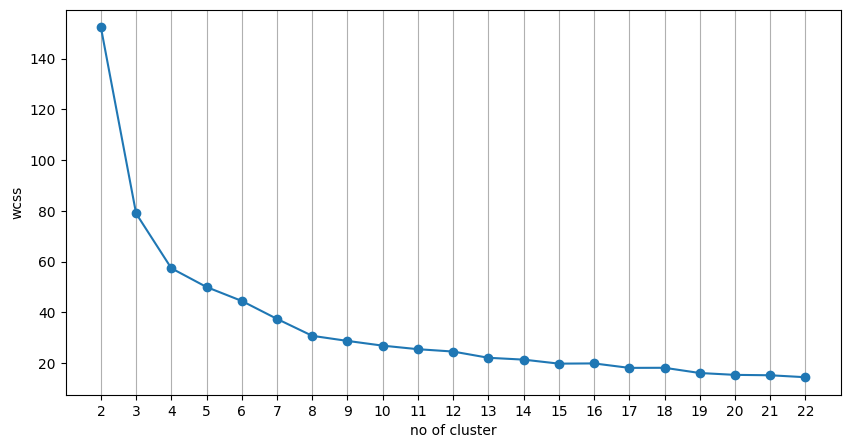

In [28]:
plt.figure(figsize=(10, 5))
plt.plot([i for i in range(2, 23)], wcss, marker="o")
plt.xlabel("no of cluster")
plt.xticks([i for i in range(2, 23)])
plt.ylabel("wcss")
plt.grid(axis="x")
plt.show()

In [29]:
kmn = KMeans(n_clusters=3)
dataset["Predict"] = kmn.fit_predict(dataset)

In [30]:
dataset

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


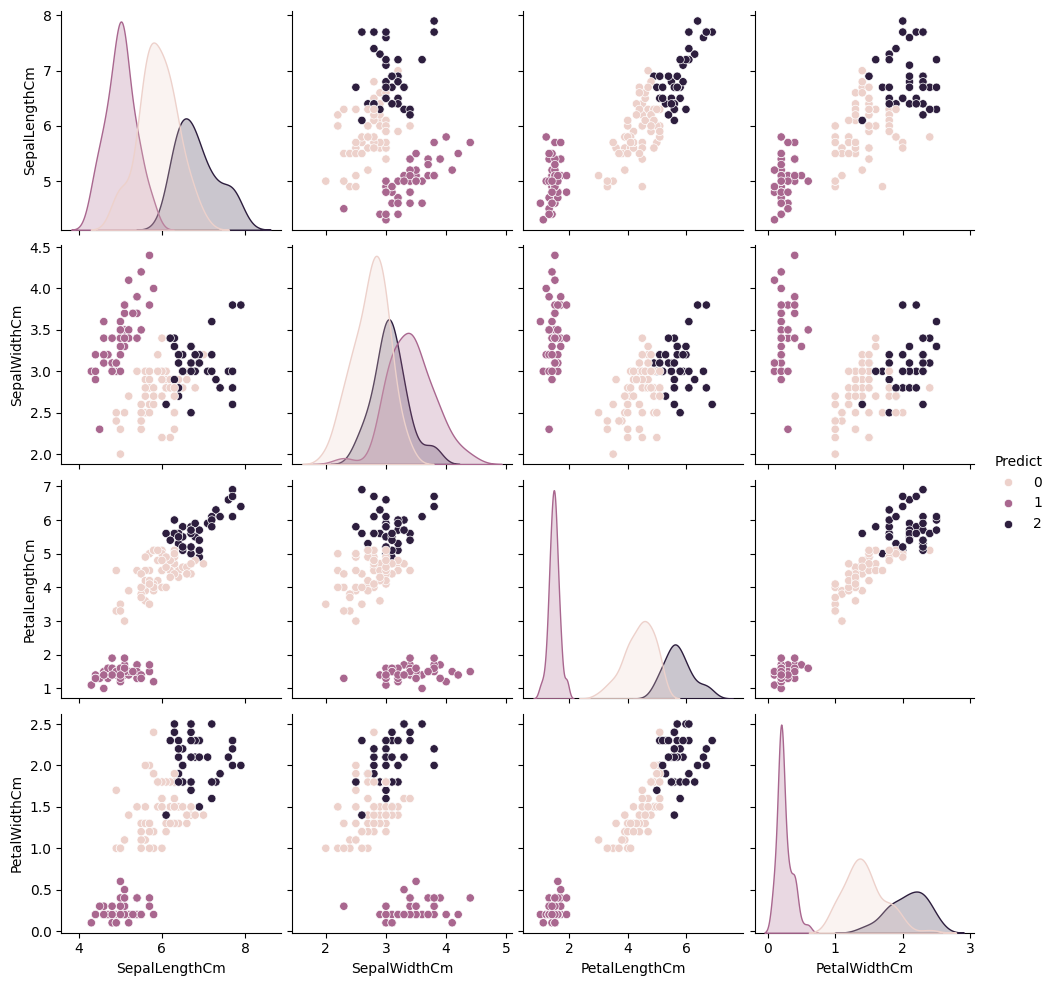

In [31]:
sns.pairplot(data = dataset, hue="Predict")
plt.savefig("Predict.jpg")
plt.show()

In [32]:
org_dataset = pd.read_csv("Iris.csv")
org_dataset.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


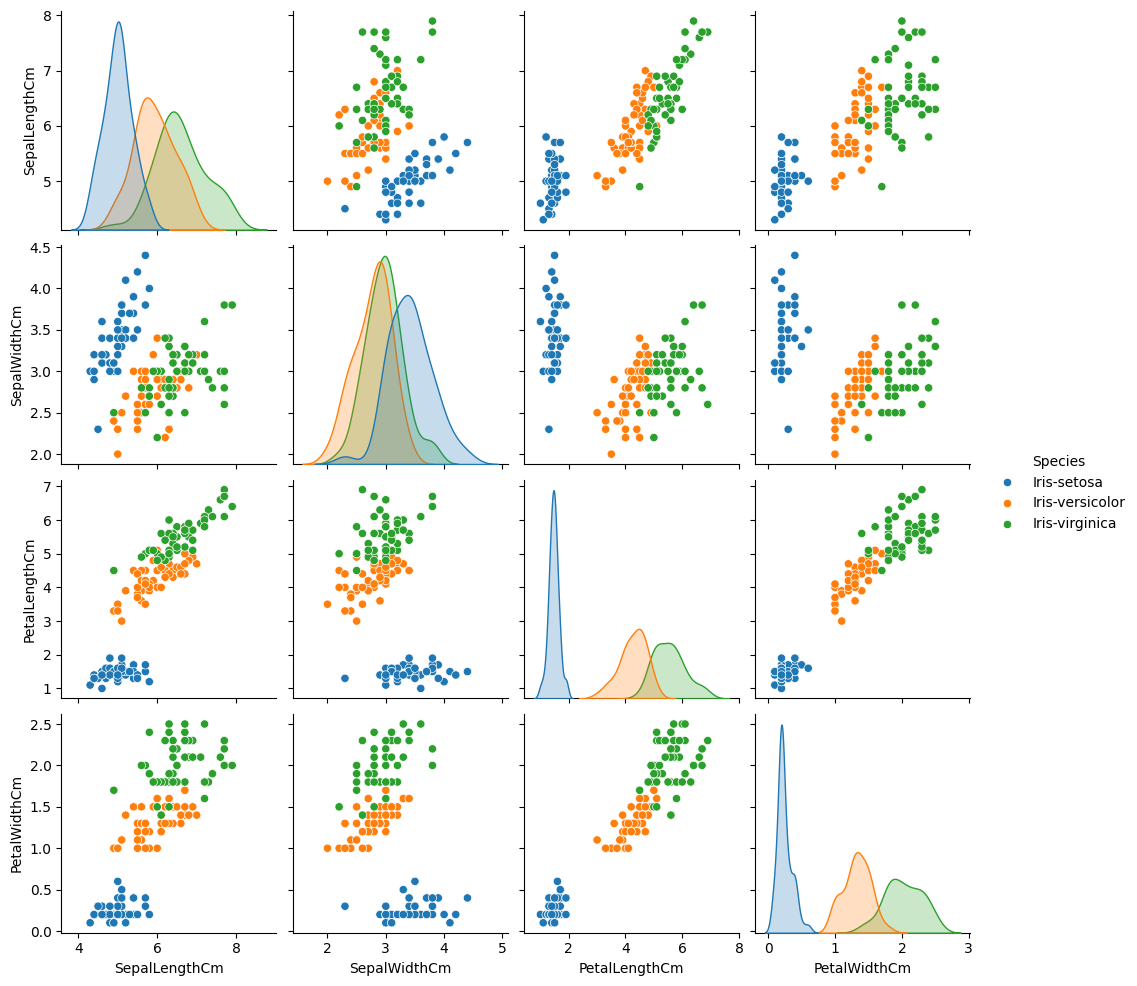

In [33]:
sns.pairplot(data = org_dataset, hue="Species")
plt.savefig("org.jpg")
plt.show()

# Silhouette Score

In [ ]:
# Silhouette Score - range -1 to 1

In [ ]:
# 1.  s(i) = b(i) - a(i)/max{a(i), b(i)} , if|Ci|>1
# 2.  s(i) = 0 , if|Ci| = 1

# 3.  s(i) = { 1 - a(i)/b(i), if a(i) < b(i)}
#            { 0,             if a(i) = b(i)}
#            { b(i)/a(i) - 1, if a(i) > b(i)}

# -1 <= s(i) <= 1

In [34]:
from sklearn.metrics import silhouette_score

In [35]:
silhouette_score(dataset, labels=kmn.labels_)

0.684936462996038

In [36]:
kmn.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [37]:
ss = []
no_c = [j for j in range(2, 21)]
for i in range(2, 21):
    km1 = KMeans(n_clusters=i)
    km1.fit(dataset)
    ss.append(silhouette_score(dataset, km1.labels_))

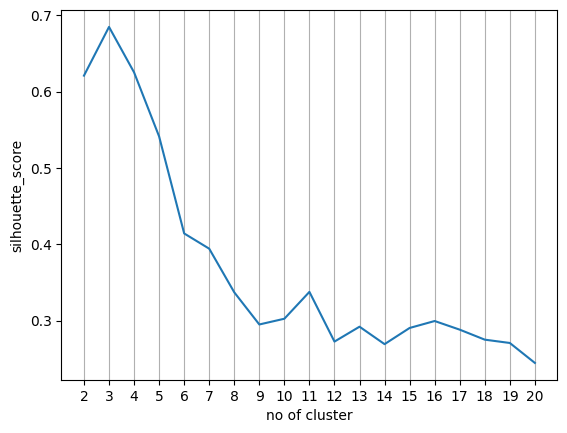

In [38]:
plt.plot(no_c, ss)
plt.xlabel("no of cluster")
plt.ylabel("silhouette_score")
plt.xticks(no_c)
plt.grid(axis="x")
plt.show()